# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("cleaned_housing.csv")

In [ ]:
df = df.fillna(df.median(numeric_only=True))

In [ ]:
# Define features and target
target = "median_house_value"
X = df.drop(target, axis=1)
y = df[target]

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
    )

In [ ]:
# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predictions
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R² Score:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

R² Score: 0.6254240620553614
MSE: 4908476721.156606
RMSE: 70060.5218447351


In [ ]:
# ADJUSTED R² SCORE
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R² Score:", adjusted_r2)

Adjusted R² Score: 0.6243317385425216


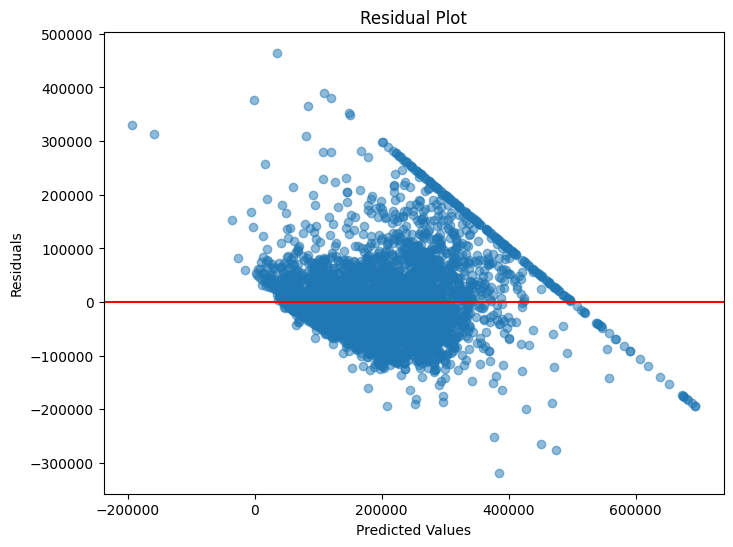

In [ ]:
# Residual Analysis
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

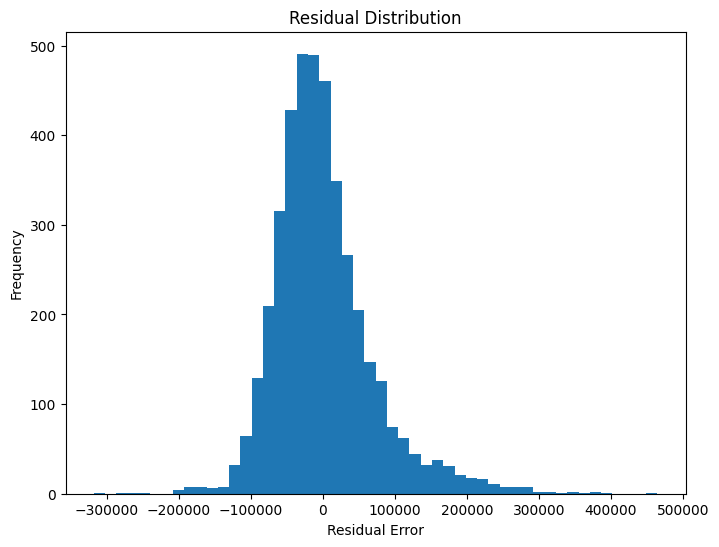

In [ ]:
#  DISTRIBUTION OF RESIDUALS
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=50)
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

In [ ]:
# FEATURE IMPORTANCE
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
print(coefficients)

                       Feature    Coefficient
9       ocean_proximity_ISLAND  136125.072615
7                median_income   39473.975175
11  ocean_proximity_NEAR OCEAN    3431.140073
2           housing_median_age    1102.185084
4               total_bedrooms     102.789395
6                   households      48.252753
3                  total_rooms      -6.021506
5                   population     -38.172906
10    ocean_proximity_NEAR BAY   -5136.642217
1                     latitude  -25468.352050
0                    longitude  -26838.273372
8       ocean_proximity_INLAND  -39786.656161


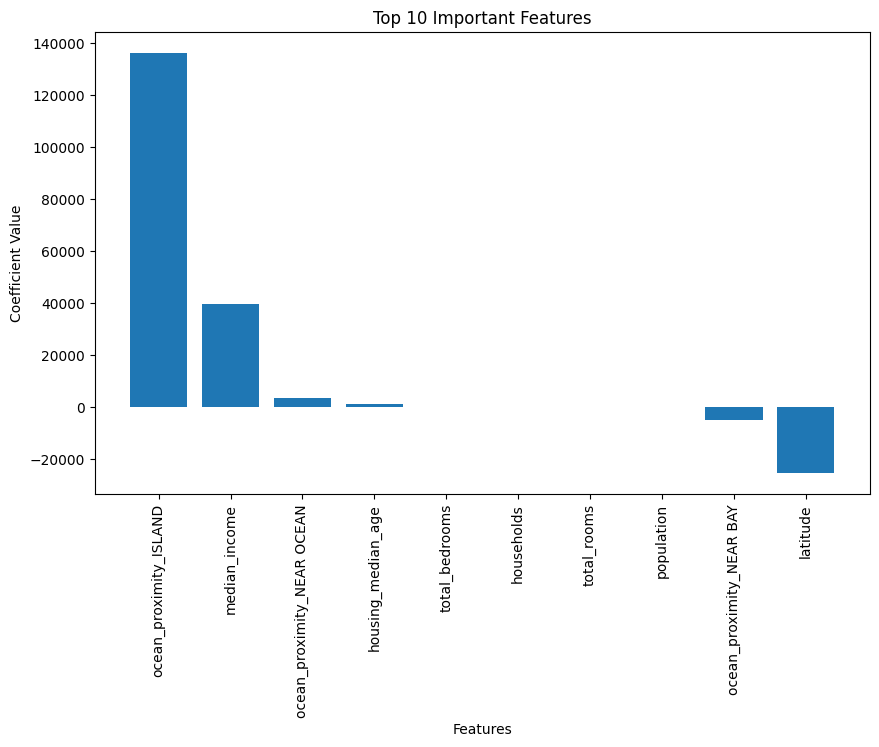

In [ ]:
top_features = coefficients.head(10)
plt.figure(figsize=(10,6))
plt.bar(top_features["Feature"], top_features["Coefficient"])
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Top 10 Important Features")
plt.show()

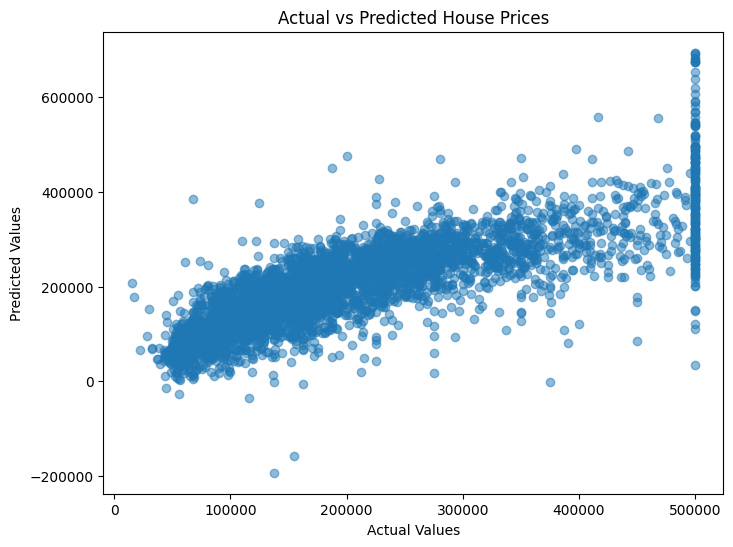

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [ ]:
# Save model results
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": residuals
})
results.to_csv("week6_model_results.csv", index=False)
print("Week 6 results saved as week6_model_results.csv")

Week 6 results saved as week6_model_results.csv


In [ ]:
# Saving trained model
joblib.dump(model, "housing_model.pkl")
print("Model is saved as housing_model.pkl")

Model is saved as housing_model.pkl


In [ ]:
# Final Summary
print("""
All done
""")


All done

